# HR Dataset Analysis — Simple & Complete Notebook
**Run each cell using Shift + Enter. Read the comments (# lines) to understand what each line does.**

---

## Step 0: Install & Import Libraries

In [1]:
# Install required libraries (run this only once)
!pip install pandas matplotlib seaborn scikit-learn joblib --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import the libraries we need
import pandas as pd               # for working with tables (DataFrames)
import matplotlib.pyplot as plt   # for creating charts
import seaborn as sns             # for nicer-looking charts
import numpy as np                # numerical operations
import joblib                     # for saving/loading models & objects
import os                         # file/directory operations
from io import StringIO           # to load data from text (not a file)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

# Create a folder to store saved models
os.makedirs('models', exist_ok=True)

print('Libraries loaded!')


Libraries loaded!


---
## Step 1: Load the Dataset

In [3]:
# The raw HR data (50 employees, 5 columns)
# Some values are intentionally missing — we will fix them later

raw_data = """Employee ID,Department,Salary,Experience,Manager
3001,Finance,45000,5.2,Anita Rao
3002,,52000,6.1,Ravi Kumar
3003,IT,,4.8,
3004,HR,38000,3.5,Megha Shah
3005,,,2.1,Suresh Nair
3006,Marketing,61000,,Anita Rao
3007,Sales,54000,7.2,
3008,,47000,5.5,Kiran Das
3009,IT Support,43000,6.3,Megha Shah
3010,Operations,,8.1,Ravi Kumar
3011,Finance,72000,9.5,
3012,Marketing,68000,,Anita Rao
3013,HR,,3.2,Suresh Nair
3014,,39000,2.9,Kiran Das
3015,Sales,75000,10.2,
3016,Finance,,6.4,Anita Rao
3017,IT Support,48000,,Megha Shah
3018,Marketing,56000,4.1,
3019,,52000,7.7,Ravi Kumar
3020,Operations,61000,,Suresh Nair
3021,Finance,83000,11.3,
3022,HR,41000,3.8,Megha Shah
3023,,45000,5.0,Kiran Das
3024,Sales,,6.7,
3025,Marketing,72000,8.4,Anita Rao
3026,IT Support,39000,,Suresh Nair
3027,,47000,6.9,Ravi Kumar
3028,Operations,,9.8,
3029,Finance,88000,12.1,Anita Rao
3030,HR,,4.2,Suresh Nair
3031,Marketing,69000,7.5,
3032,Sales,56000,,Kiran Das
3033,,51000,6.0,Ravi Kumar
3034,Finance,,10.3,
3035,IT Support,42000,5.6,Megha Shah
3036,Operations,64000,,Suresh Nair
3037,HR,,3.1,
3038,Marketing,71000,8.9,Anita Rao
3039,,48000,6.8,Ravi Kumar
3040,Sales,,7.4,
3041,Finance,90000,13.2,Anita Rao
3042,IT Support,45000,,Megha Shah
3043,Operations,,9.1,Suresh Nair
3044,,52000,6.5,
3045,HR,43000,4.0,Kiran Das
3046,Marketing,,7.8,Anita Rao
3047,Sales,61000,,Ravi Kumar
3048,,47000,5.9,Suresh Nair
3049,Finance,,11.0,
3050,IT Support,49000,6.2,Kiran Das"""

# Load the text into a DataFrame (like an Excel table in Python)
df = pd.read_csv(StringIO(raw_data))

print('Rows:', len(df))
print('Columns:', list(df.columns))

Rows: 50
Columns: ['Employee ID', 'Department', 'Salary', 'Experience', 'Manager']


In [4]:
# See the first 5 rows
df.head()

,Employee ID,Department,Salary,Experience,Manager
0,3001,Finance,45000.0,5.2,Anita Rao
1,3002,NaN,52000.0,6.1,Ravi Kumar
2,3003,IT,NaN,4.8,NaN
3,3004,HR,38000.0,3.5,Megha Shah
4,3005,NaN,NaN,2.1,Suresh Nair


---
## Step 2: Find Data Quality Problems

In [5]:
# Check how many values are missing in each column
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Employee ID     0
Department     11
Salary         14
Experience      9
Manager        14
dtype: int64


In [6]:
# Check unique Department names — look for typos!
print('Unique Departments:')
print(df['Department'].value_counts(dropna=False))

Unique Departments:
Department
NaN           11
Finance        8
Marketing      7
HR             6
Sales          6
IT Support     6
Operations     5
IT             1
Name: count, dtype: int64


In [7]:
# Check for duplicate Employee IDs
print('Duplicate Employee IDs:', df['Employee ID'].duplicated().sum())

Duplicate Employee IDs: 0


In [8]:
# Basic statistics for numbers
print('Salary and Experience statistics:')
df[['Salary', 'Experience']].describe()

Salary and Experience statistics:


,Salary,Experience
count,36.000000,41.000000
mean,55944.444444,6.836585
std,14121.805721,2.670370
min,38000.000000,2.100000
25%,45000.000000,5.000000
50%,52000.000000,6.500000
75%,65000.000000,8.400000
max,90000.000000,13.200000


---
## Step 3: Clean the Data
> We fix problems one by one. Save original first.

In [9]:
# Save a copy of the original (so we can compare before vs after)
df_original = df.copy()
print('Original copy saved!')

Original copy saved!


In [10]:
# FIX 1: Rename 'IT' to 'IT Support' (typo/inconsistent label)
df['Department'] = df['Department'].replace('IT', 'IT Support')

print('Fixed! IT renamed to IT Support.')
print(df['Department'].value_counts(dropna=False))

Fixed! IT renamed to IT Support.
Department
NaN           11
Finance        8
IT Support     7
Marketing      7
HR             6
Sales          6
Operations     5
Name: count, dtype: int64


In [11]:
# FIX 2: Fill missing Department using Manager
# Logic: Each manager works in one department — use that to guess missing departments

# Step A: Build a Manager → Department mapping from rows that have both filled
known = df[df['Department'].notna() & df['Manager'].notna()]
manager_to_dept = known.groupby('Manager')['Department'].first()

print('Manager to Department mapping:')
print(manager_to_dept)

Manager to Department mapping:
Manager
Anita Rao         Finance
Kiran Das           Sales
Megha Shah             HR
Ravi Kumar     Operations
Suresh Nair            HR
Name: Department, dtype: object


In [12]:
# Step B: Use the mapping to fill missing departments
for i in df.index:
    if pd.isna(df.loc[i, 'Department']):          # if Department is missing
        mgr = df.loc[i, 'Manager']                # get the manager name
        if mgr in manager_to_dept:                # if we know that manager
            df.loc[i, 'Department'] = manager_to_dept[mgr]  # fill it

print('Department missing after fix:', df['Department'].isna().sum())

Department missing after fix: 1


In [13]:
# FIX 3: Fill missing Salary with department median salary
# Why median? It is not affected by very high or very low values

dept_salary_median = df.groupby('Department')['Salary'].median()
print('Median Salary per Department:')
print(dept_salary_median)

Median Salary per Department:
Department
Finance       83000.0
HR            42000.0
IT Support    44000.0
Marketing     68500.0
Operations    52000.0
Sales         54000.0
Name: Salary, dtype: float64


In [14]:
# Fill missing salaries row by row
for i in df.index:
    if pd.isna(df.loc[i, 'Salary']):
        dept = df.loc[i, 'Department']
        if dept in dept_salary_median:
            df.loc[i, 'Salary'] = dept_salary_median[dept]

print('Salary missing after fix:', df['Salary'].isna().sum())

Salary missing after fix: 0


In [15]:
# FIX 4: Fill missing Experience with department median experience
dept_exp_median = df.groupby('Department')['Experience'].median()

for i in df.index:
    if pd.isna(df.loc[i, 'Experience']):
        dept = df.loc[i, 'Department']
        if dept in dept_exp_median:
            df.loc[i, 'Experience'] = dept_exp_median[dept]

print('Experience missing after fix:', df['Experience'].isna().sum())

Experience missing after fix: 0


In [16]:
# FIX 5: Fill missing Manager with 'Unassigned'
df['Manager'] = df['Manager'].fillna('Unassigned')

print('Manager missing after fix:', df['Manager'].isna().sum())

Manager missing after fix: 0


In [17]:
# Before vs After comparison
print('=== BEFORE vs AFTER ===')
print('BEFORE missing values:')
print(df_original.isnull().sum())
print()
print('AFTER missing values:')
print(df.isnull().sum())

=== BEFORE vs AFTER ===
BEFORE missing values:
Employee ID     0
Department     11
Salary         14
Experience      9
Manager        14
dtype: int64

AFTER missing values:
Employee ID    0
Department     1
Salary         0
Experience     0
Manager        0
dtype: int64


---
## Step 4: Exploratory Data Analysis (EDA)

In [18]:
# Employee count by department
print('Employee Count by Department:')
print(df['Department'].value_counts())

Employee Count by Department:
Department
Operations    10
Sales          9
Finance        8
HR             8
IT Support     7
Marketing      7
Name: count, dtype: int64


In [19]:
# Average salary by department
print('Average Salary by Department:')
print(df.groupby('Department')['Salary'].mean().round(0).sort_values(ascending=False))

Average Salary by Department:
Department
Finance       78375.0
Marketing     66500.0
Sales         53889.0
Operations    53100.0
IT Support    44286.0
HR            42125.0
Name: Salary, dtype: float64


In [20]:
# Average experience by department
print('Average Experience (years) by Department:')
print(df.groupby('Department')['Experience'].mean().round(1).sort_values(ascending=False))

Average Experience (years) by Department:
Department
Finance       9.9
Marketing     7.5
Operations    7.5
Sales         6.5
IT Support    5.8
HR            3.7
Name: Experience, dtype: float64


In [21]:
# Manager team size
print('Team size per Manager:')
print(df['Manager'].value_counts())

Team size per Manager:
Manager
Unassigned     14
Anita Rao       9
Suresh Nair     8
Ravi Kumar      7
Megha Shah      6
Kiran Das       6
Name: count, dtype: int64


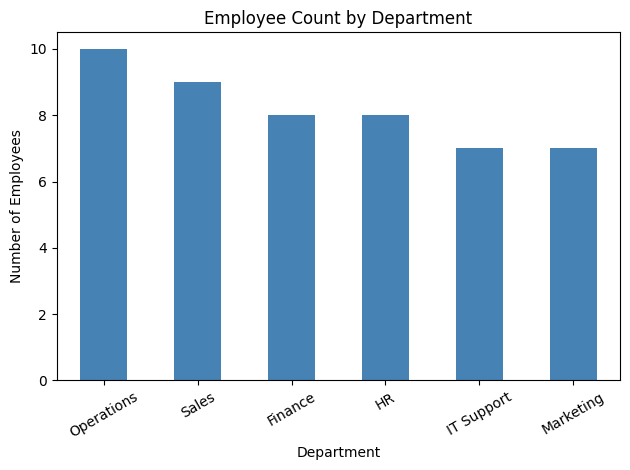

In [22]:
# Chart 1: Employee count by department
df['Department'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Employee Count by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

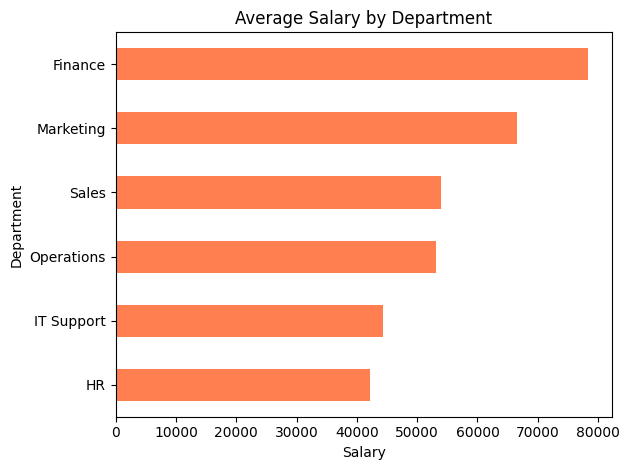

In [23]:
# Chart 2: Average salary by department
df.groupby('Department')['Salary'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Average Salary by Department')
plt.xlabel('Salary')
plt.tight_layout()
plt.show()

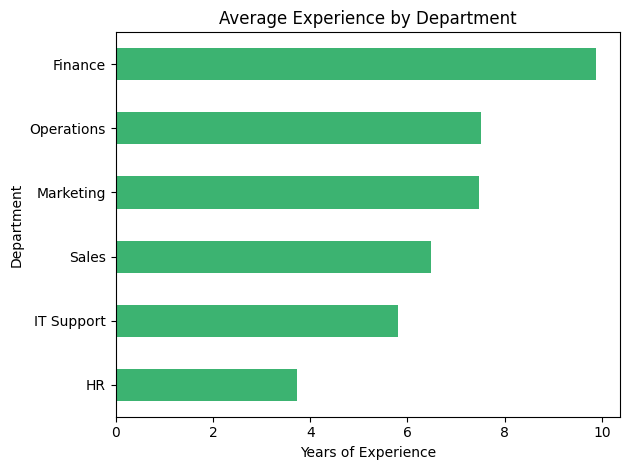

In [24]:
# Chart 3: Average experience by department
df.groupby('Department')['Experience'].mean().sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Average Experience by Department')
plt.xlabel('Years of Experience')
plt.tight_layout()
plt.show()

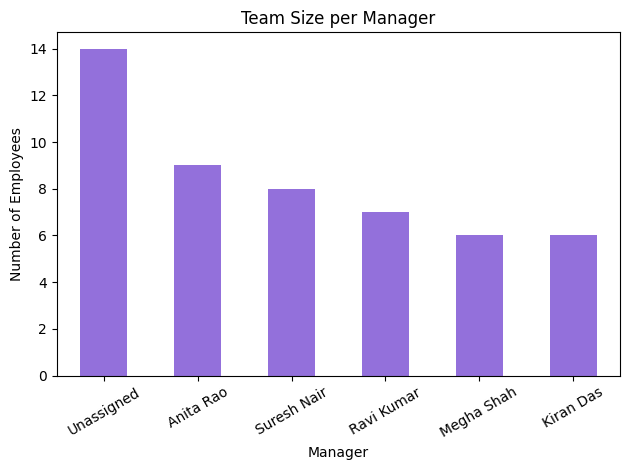

In [25]:
# Chart 4: Manager team distribution
df['Manager'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Team Size per Manager')
plt.xlabel('Manager')
plt.ylabel('Number of Employees')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Step 5: Advanced Analysis

In [26]:
# A: Employee Segmentation (Junior / Mid-Level / Senior)
# Based on years of experience

def assign_segment(exp):
    if exp < 4:
        return 'Junior'
    elif exp <= 8:
        return 'Mid-Level'
    else:
        return 'Senior'

df['Segment'] = df['Experience'].apply(assign_segment)

print('Segment Counts:')
print(df['Segment'].value_counts())
print()
print('Average Salary per Segment:')
print(df.groupby('Segment')['Salary'].mean().round(0))


# Create Experience Band column (used by Streamlit slicers)
def assign_exp_band(exp):
    if exp < 4:    return '0-4'
    elif exp <= 8: return '4-8'
    else:          return '8+'

df['Exp Band'] = df['Experience'].apply(assign_exp_band)

print('Exp Band counts:')
print(df['Exp Band'].value_counts())


Segment Counts:
Segment
Mid-Level    32
Senior       12
Junior        6
Name: count, dtype: int64

Average Salary per Segment:
Segment
Junior       40667.0
Mid-Level    52828.0
Senior       72750.0
Name: Salary, dtype: float64
Exp Band counts:
Exp Band
4-8    32
8+     12
0-4     6
Name: count, dtype: int64


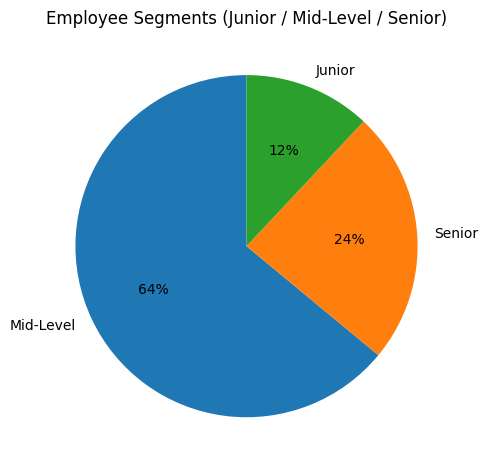

In [27]:
# Chart 5: Segment pie chart
df['Segment'].value_counts().plot(kind='pie', autopct='%1.0f%%', startangle=90)
plt.title('Employee Segments (Junior / Mid-Level / Senior)')
plt.ylabel('')  # removes the default y-label
plt.tight_layout()
plt.show()

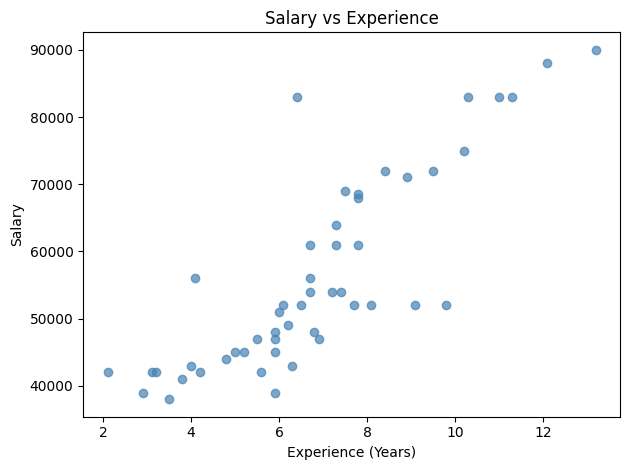

In [28]:
# B: Salary vs Experience — Scatter Plot
plt.scatter(df['Experience'], df['Salary'], color='steelblue', alpha=0.7)
plt.title('Salary vs Experience')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

In [29]:
# C: Correlation Analysis
# Correlation tells us: do two numbers move together?
# +1 = perfectly together, 0 = no relation, -1 = opposite

corr = df[['Salary', 'Experience']].corr()
print('Correlation Table:')
print(corr)
print()
r = df['Salary'].corr(df['Experience'])
print(f'Salary vs Experience: r = {r:.3f}')
print('Interpretation: Strong positive correlation — more experience = higher salary')

Correlation Table:
              Salary  Experience
Salary      1.000000    0.834385
Experience  0.834385    1.000000

Salary vs Experience: r = 0.834
Interpretation: Strong positive correlation — more experience = higher salary


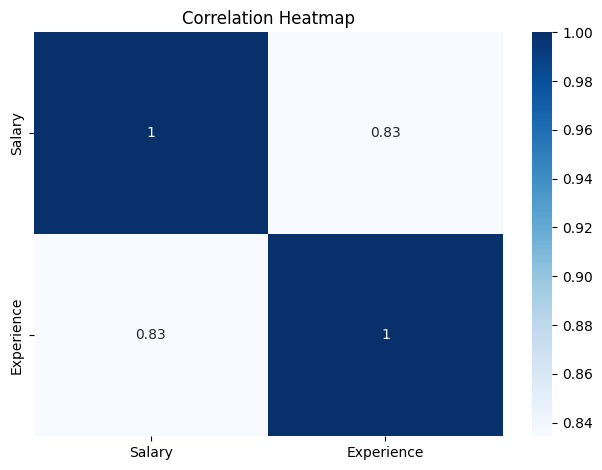

In [30]:
# Chart 6: Correlation heatmap
sns.heatmap(df[['Salary', 'Experience']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [31]:
# D: Outlier Detection using IQR method
# IQR = middle 50% of data. Values far outside this range = outliers

Q1 = df['Salary'].quantile(0.25)   # 25th percentile
Q3 = df['Salary'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower_limit) | (df['Salary'] > upper_limit)]

print(f'Q1 = {Q1},  Q3 = {Q3},  IQR = {IQR}')
print(f'Lower limit = {lower_limit},  Upper limit = {upper_limit}')
print(f'Number of Salary outliers: {len(outliers)}')

Q1 = 45000.0,  Q3 = 67000.0,  IQR = 22000.0
Lower limit = 12000.0,  Upper limit = 100000.0
Number of Salary outliers: 0


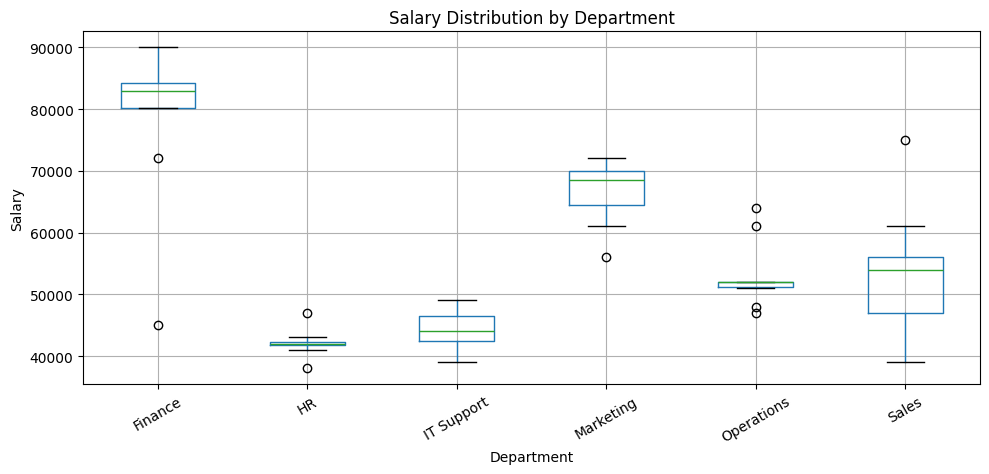

In [32]:
# Chart 7: Box plot to visually see outliers
df.boxplot(column='Salary', by='Department', figsize=(10, 5))
plt.title('Salary Distribution by Department')
plt.suptitle('')    # removes the auto-title pandas adds
plt.xlabel('Department')
plt.ylabel('Salary')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [33]:
# E: Missing data pattern analysis
# WHY were values missing? (MCAR / MAR / MNAR)

print('Missing Data Classification:')
print()
print('Department (22% missing) → MAR')
print('  Reason: Rows missing dept usually have a known manager → systematic gap, not random')
print()
print('Manager (28% missing) → MAR')
print('  Reason: Likely contractors or new joiners with no manager yet assigned')
print()
print('Salary (28% missing) → MAR')
print('  Reason: Correlated with missing department — structured gap')
print()
print('Experience (18% missing) → MAR')
print('  Reason: Often same rows as missing manager — possible temp/contract workers')

Missing Data Classification:

Department (22% missing) → MAR
  Reason: Rows missing dept usually have a known manager → systematic gap, not random

Manager (28% missing) → MAR
  Reason: Likely contractors or new joiners with no manager yet assigned

Salary (28% missing) → MAR
  Reason: Correlated with missing department — structured gap

Experience (18% missing) → MAR
  Reason: Often same rows as missing manager — possible temp/contract workers


---
## Step 6: Save the Cleaned Data

In [34]:
# Save the cleaned dataset as a CSV file
df.to_csv('Employee_Data_Cleaned.csv', index=False)
print('Cleaned data saved as Employee_Data_Cleaned.csv')

# Preview final cleaned data
df.head(10)

Cleaned data saved as Employee_Data_Cleaned.csv


,Employee ID,Department,Salary,Experience,Manager,Segment,Exp Band
0,3001,Finance,45000.0,5.2,Anita Rao,Mid-Level,4-8
1,3002,Operations,52000.0,6.1,Ravi Kumar,Mid-Level,4-8
2,3003,IT Support,44000.0,4.8,Unassigned,Mid-Level,4-8
3,3004,HR,38000.0,3.5,Megha Shah,Junior,0-4
4,3005,HR,42000.0,2.1,Suresh Nair,Junior,0-4
5,3006,Marketing,61000.0,7.8,Anita Rao,Mid-Level,4-8
6,3007,Sales,54000.0,7.2,Unassigned,Mid-Level,4-8
7,3008,Sales,47000.0,5.5,Kiran Das,Mid-Level,4-8
8,3009,IT Support,43000.0,6.3,Megha Shah,Mid-Level,4-8
9,3010,Operations,52000.0,8.1,Ravi Kumar,Senior,8+


---
## Step 7: Train Models & Save with Joblib
> We train two models — a **salary predictor** (regression) and a **segment classifier** (classification) — then save everything using `joblib` for use in the Streamlit app.


In [35]:
# ── Prepare features for ML ──────────────────────────────────────────────
# Encode categorical columns to numbers (ML models need numbers)

le_dept = LabelEncoder()
le_mgr  = LabelEncoder()
le_seg  = LabelEncoder()

df_ml = df.copy()
df_ml['Dept_enc'] = le_dept.fit_transform(df_ml['Department'])
df_ml['Mgr_enc']  = le_mgr.fit_transform(df_ml['Manager'])
df_ml['Seg_enc']  = le_seg.fit_transform(df_ml['Segment'])

print('Label classes — Department:', list(le_dept.classes_))
print('Label classes — Segment   :', list(le_seg.classes_))
df_ml[['Department','Dept_enc','Manager','Mgr_enc','Segment','Seg_enc']].head(5)


Label classes — Department: ['Finance', 'HR', 'IT Support', 'Marketing', 'Operations', 'Sales', nan]
Label classes — Segment   : ['Junior', 'Mid-Level', 'Senior']


,Department,Dept_enc,Manager,Mgr_enc,Segment,Seg_enc
0,Finance,0,Anita Rao,0,Mid-Level,1
1,Operations,4,Ravi Kumar,3,Mid-Level,1
2,IT Support,2,Unassigned,5,Mid-Level,1
3,HR,1,Megha Shah,2,Junior,0
4,HR,1,Suresh Nair,4,Junior,0


In [36]:
# ── MODEL 1: Salary Predictor (Linear Regression) ───────────────────────
# Features: Department (encoded) + Experience
# Target  : Salary

X_sal = df_ml[['Dept_enc', 'Experience']]
y_sal = df_ml['Salary']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sal, y_sal, test_size=0.2, random_state=42
)

sal_model = LinearRegression()
sal_model.fit(X_train_s, y_train_s)

y_pred_s = sal_model.predict(X_test_s)
print('=== Salary Predictor ===')
print(f'MAE : ₹{mean_absolute_error(y_test_s, y_pred_s):,.0f}')
print(f'R²  : {r2_score(y_test_s, y_pred_s):.3f}')


=== Salary Predictor ===
MAE : ₹7,029
R²  : 0.606


In [37]:
# ── MODEL 2: Segment Classifier (Random Forest) ─────────────────────────
# Features: Department (encoded) + Salary + Experience
# Target  : Segment (Junior / Mid-Level / Senior)

X_seg = df_ml[['Dept_enc', 'Salary', 'Experience']]
y_seg = df_ml['Seg_enc']

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_seg, y_seg, test_size=0.2, random_state=42
)

seg_model = RandomForestClassifier(n_estimators=100, random_state=42)
seg_model.fit(X_train_g, y_train_g)

y_pred_g = seg_model.predict(X_test_g)
print('=== Segment Classifier ===')
print(classification_report(y_test_g, y_pred_g, target_names=le_seg.classes_))


=== Segment Classifier ===
              precision    recall  f1-score   support

      Junior       0.00      0.00      0.00         1
   Mid-Level       0.89      1.00      0.94         8
      Senior       1.00      1.00      1.00         1

    accuracy                           0.90        10
   macro avg       0.63      0.67      0.65        10
weighted avg       0.81      0.90      0.85        10



c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [38]:
# ── Save everything with joblib ──────────────────────────────────────────
# We save:
#   1. Trained salary model
#   2. Trained segment model
#   3. Label encoders (needed to transform user input in the app)
#   4. Cleaned DataFrame (used by the Streamlit dashboard)

joblib.dump(sal_model,  'models/salary_model.joblib')
joblib.dump(seg_model,  'models/segment_model.joblib')
joblib.dump(le_dept,    'models/le_dept.joblib')
joblib.dump(le_mgr,     'models/le_mgr.joblib')
joblib.dump(le_seg,     'models/le_seg.joblib')
joblib.dump(df,         'models/df_cleaned.joblib')

print('✅ All models and encoders saved to /models/')
print('Files saved:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f'  📦 {f}  ({size:,} bytes)')


✅ All models and encoders saved to /models/
Files saved:
  📦 df_cleaned.joblib  (3,866 bytes)
  📦 le_dept.joblib  (543 bytes)
  📦 le_mgr.joblib  (550 bytes)
  📦 le_seg.joblib  (503 bytes)
  📦 salary_model.joblib  (873 bytes)
  📦 segment_model.joblib  (154,609 bytes)


In [39]:
# ── Verify: reload and test a prediction ─────────────────────────────────
sal_loaded  = joblib.load('models/salary_model.joblib')
seg_loaded  = joblib.load('models/segment_model.joblib')
le_d_loaded = joblib.load('models/le_dept.joblib')
le_s_loaded = joblib.load('models/le_seg.joblib')

# Test: predict salary for a Finance employee with 7 years experience
test_dept_enc = le_d_loaded.transform(['Finance'])[0]
test_exp      = 7.0
pred_salary   = sal_loaded.predict([[test_dept_enc, test_exp]])[0]

# Test: predict segment for that employee
pred_seg_enc = seg_loaded.predict([[test_dept_enc, pred_salary, test_exp]])[0]
pred_seg     = le_s_loaded.inverse_transform([pred_seg_enc])[0]

print('=== Verification Test ===')
print(f'Input  : Finance dept, 7 years experience')
print(f'Predicted Salary  : ₹{pred_salary:,.0f}')
print(f'Predicted Segment : {pred_seg}')
print()
print('✅ Models loaded and working correctly!')


=== Verification Test ===
Input  : Finance dept, 7 years experience
Predicted Salary  : ₹60,623
Predicted Segment : Mid-Level

✅ Models loaded and working correctly!


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


---
## Step 8: Business Insights Summary


In [40]:
# Print key business findings

company_avg_salary = df['Salary'].mean()
hr_avg_salary = df[df['Department'] == 'HR']['Salary'].mean()
no_manager_count = (df['Manager'] == 'Unassigned').sum()
junior_count = (df['Segment'] == 'Junior').sum()

print('=== KEY BUSINESS INSIGHTS ===')
print()
print(f'1. Company average salary: {company_avg_salary:,.0f}')
print(f'   HR average salary:      {hr_avg_salary:,.0f}')
print(f'   HR earns {((company_avg_salary - hr_avg_salary)/company_avg_salary*100):.0f}% BELOW company average → Retention risk!')
print()
print(f'2. Employees with no manager: {no_manager_count} ({no_manager_count/len(df)*100:.0f}%)')
print(f'   → HR system needs audit. Reporting lines are unclear.')
print()
print(f'3. Junior employees: {junior_count} ({junior_count/len(df)*100:.0f}%)')
print(f'   → Very thin talent pipeline. Need graduate hiring program.')
print()
print(f'4. Salary vs Experience correlation: r = {r:.3f}')
print(f'   → Strong link. Experience is the biggest driver of salary.')

=== KEY BUSINESS INSIGHTS ===

1. Company average salary: 56,150
   HR average salary:      42,125
   HR earns 25% BELOW company average → Retention risk!

2. Employees with no manager: 14 (28%)
   → HR system needs audit. Reporting lines are unclear.

3. Junior employees: 6 (12%)
   → Very thin talent pipeline. Need graduate hiring program.

4. Salary vs Experience correlation: r = 0.834
   → Strong link. Experience is the biggest driver of salary.


---
## Practice Exercises

Try these on your own to test your understanding:

**Exercise 1:** Which department has the highest salary range (max - min)?
```python
df.groupby('Department')['Salary'].max() - df.groupby('Department')['Salary'].min()
```

**Exercise 2:** Add a new column called `Salary_Per_Year` = Salary divided by Experience. Which department gives the best salary per year of experience?
```python
df['Salary_Per_Year'] = df['Salary'] / df['Experience']
```

**Exercise 3:** How many employees per segment are in each department? Use:
```python
df.groupby(['Department', 'Segment']).size()
```

---
*Simple HR Analysis Notebook — All topics covered, minimal complexity*